# Compositional Contextual Expert Bandits [CCEB]

## Part 1: Defining The Inference System

In [1]:
import torch
from pathlib import Path

# Disable gradient calculations globally
torch.set_grad_enabled(False)
# Set so that each particle will only use one thread
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
# set torch print options, including line width
torch.set_printoptions(precision=4, sci_mode=False, linewidth=250)

import numpy as np
import pickle
import torch.distributions as D
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm.notebook import tqdm
import gc

In [2]:
from idealobserver import IdealObsPF
from experiment import (
    ExperimentalCRP,
    IOPFSubjectHistory,
    ExperimentHistory,
    CombinedHistory,
)
from utils_mcl import extract_context_params

## Part 1: Load experiment statistics from simulations

In [3]:
mcl_results_path = Path("mcl_results")
results_folder = (
    mcl_results_path
    / "prepost_static_ys_one_h_init_meta_no_y_init_rho_dim_1_removed"
    / "fourth_pass_sim"
)
results_dcoin_folder = results_folder / "dCOIN" / "cceb"
results_dcoin_folder.mkdir(parents=True, exist_ok=True)

In [4]:
observations = np.load(results_folder / "stimuli")
T, B, _ = observations.shape

contexts = np.loadtxt(results_folder / "ctxs")
# Context length: number of consecutive timesteps for each context
changes = np.where(contexts[1:] != contexts[:-1])[0] + 1
ctx_length = changes[0] if len(changes) > 0 else T

# Optional: verify that transitions are regular
if len(changes) > 1:
    lengths = np.diff(np.concatenate(([0], changes, [T])))
    if not np.all(lengths == ctx_length):
        raise ValueError(f"Context transitions are not regular: {lengths}")
n_blocks = int(T / (ctx_length * 2))
b = 50

## Part 2: Run Simulation

In [5]:
HYP_CJCRP = {
    "gamma": 0.1,
    "alpha_o": 0.5,
    "alpha_r": 0.5,
}
HYP_NIW = {
    "mu0": torch.tensor([0.0, 0.0]),
    "kappa0": 0.1,
    "nu0": 4.0,
    "Lambda0": torch.eye(2) * 1.0,
}
HYP_BB = {
    "alpha0": torch.tensor([0.05, 0.05, 0.05, 0.05]),
    "beta0": torch.tensor([0.5, 0.5, 0.5, 0.5]),
}

HYP = {"hyp_cjcrp": HYP_CJCRP, "hyp_niw": HYP_NIW, "hyp_bb": HYP_BB}
N_particles = 250

#### Simulation

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

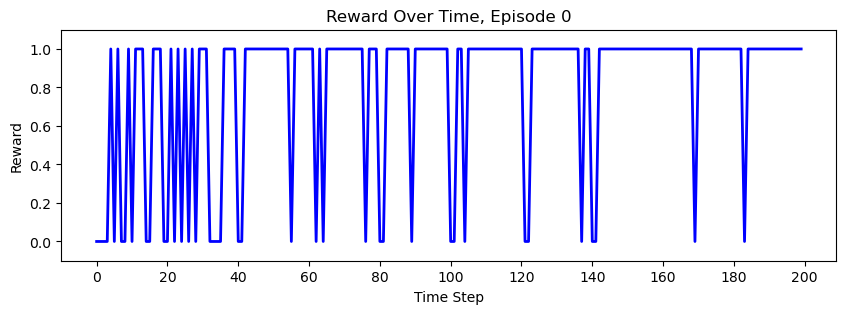

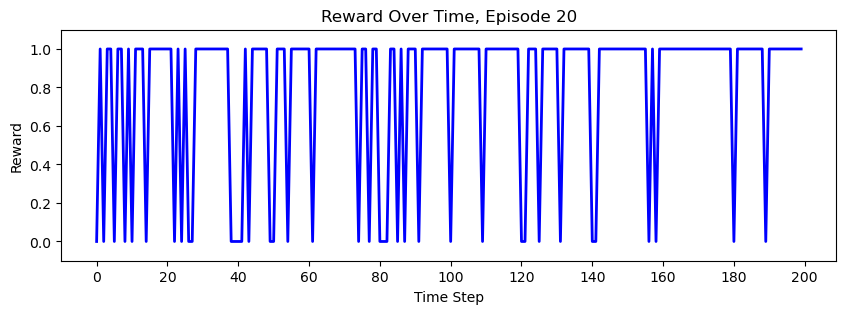

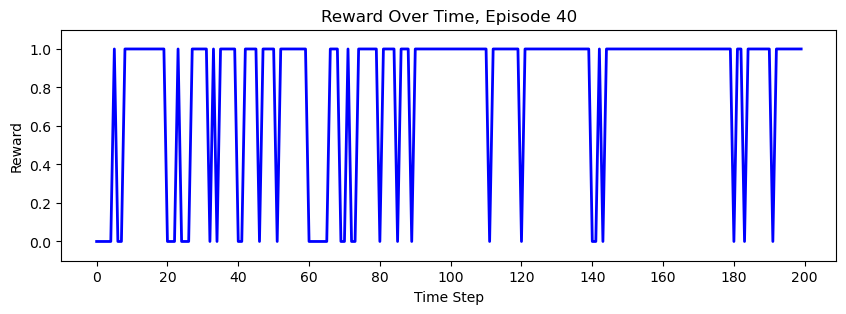

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

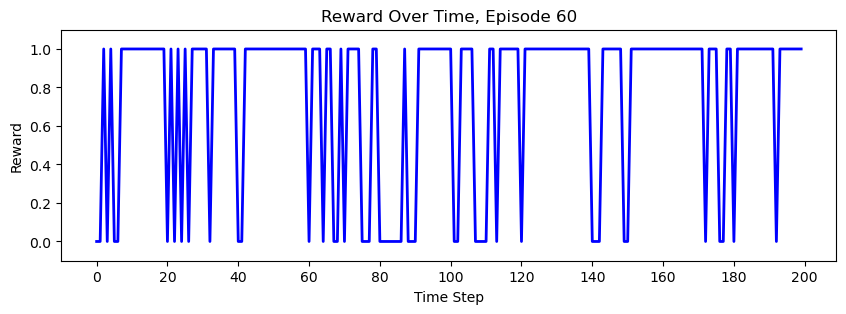

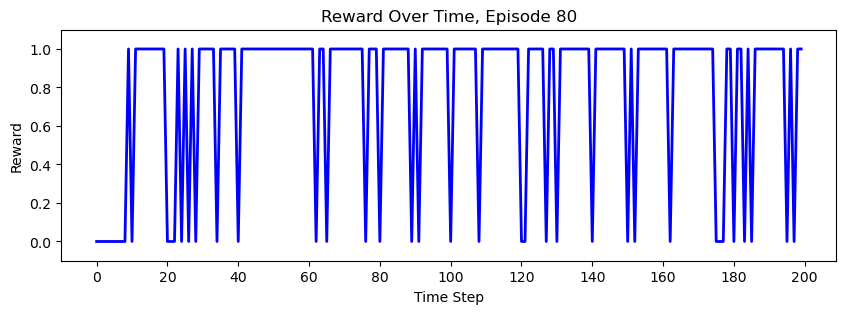

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

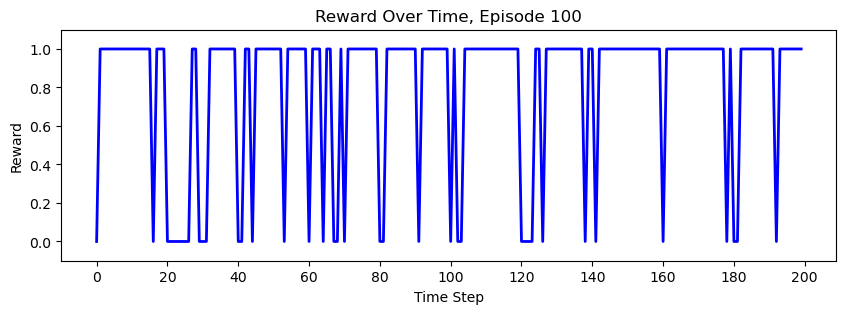

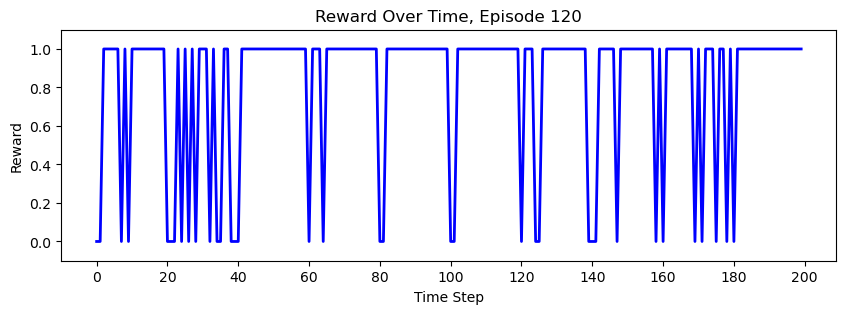

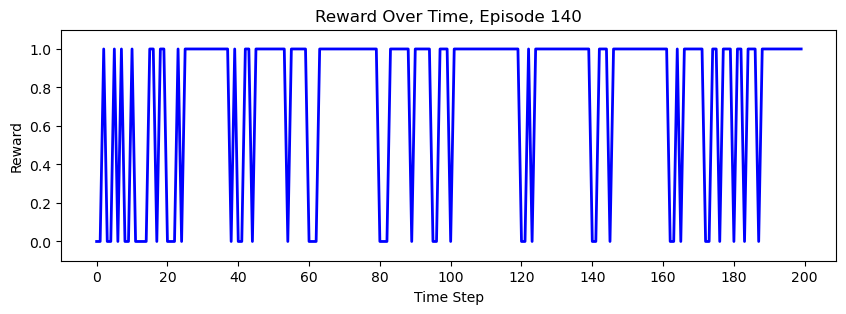

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

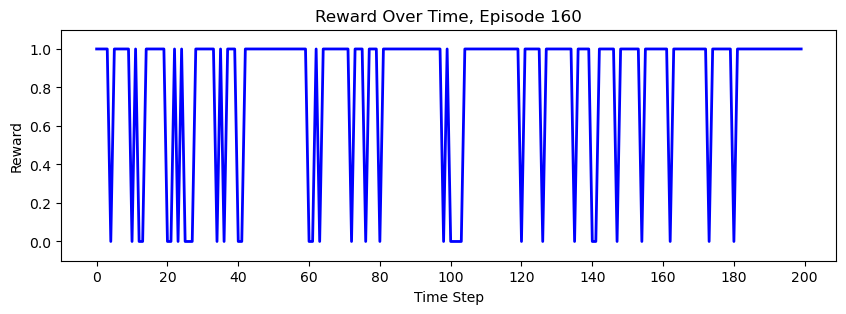

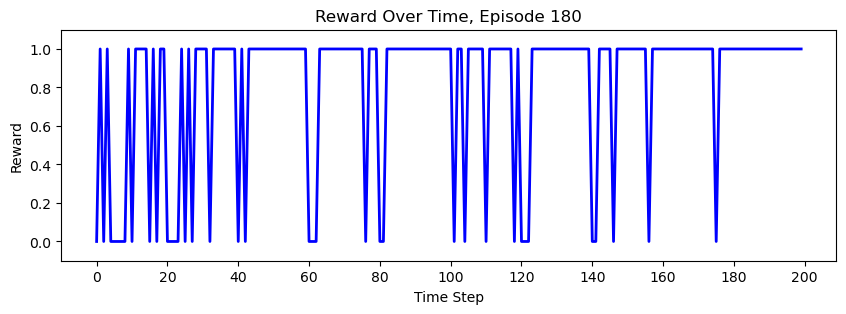

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

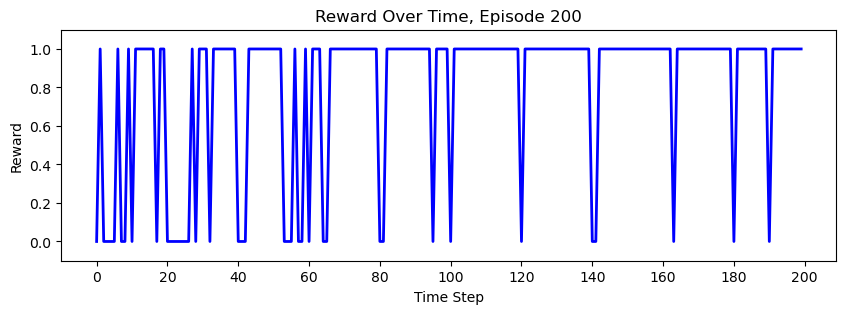

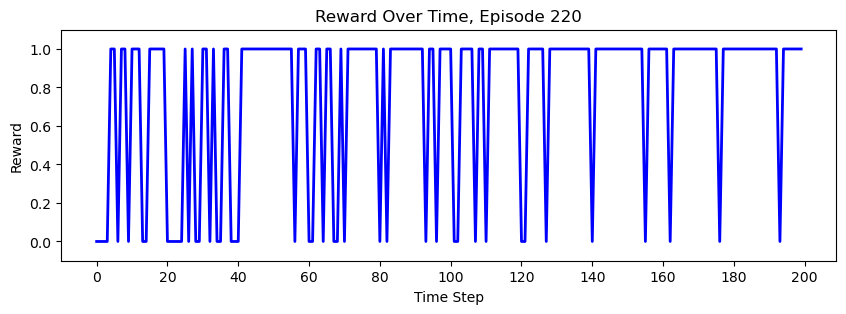

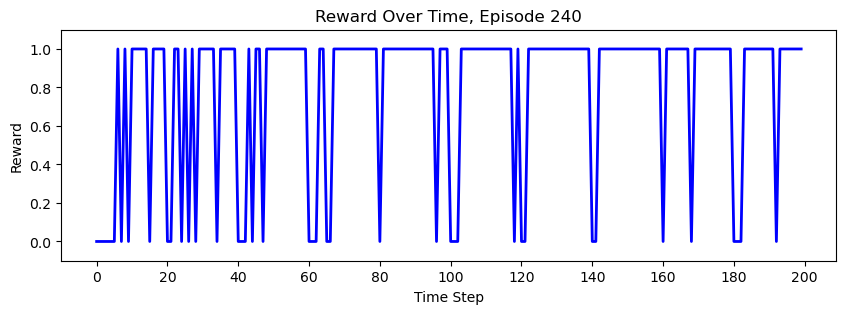

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

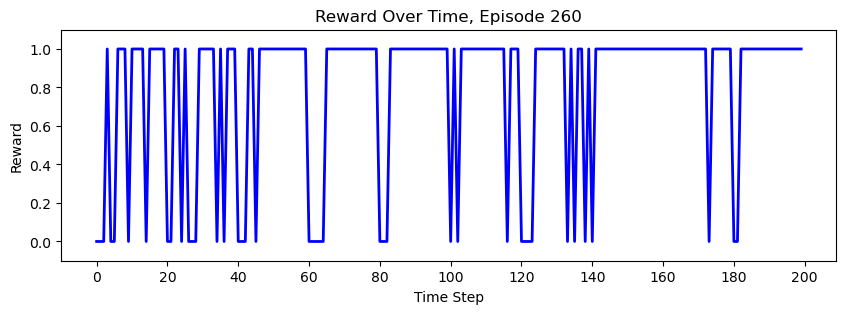

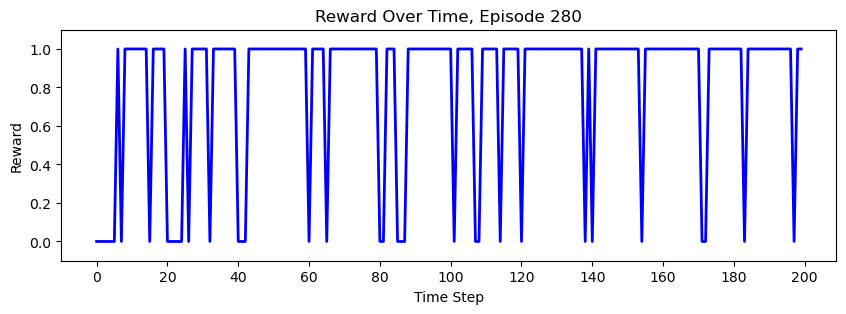

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

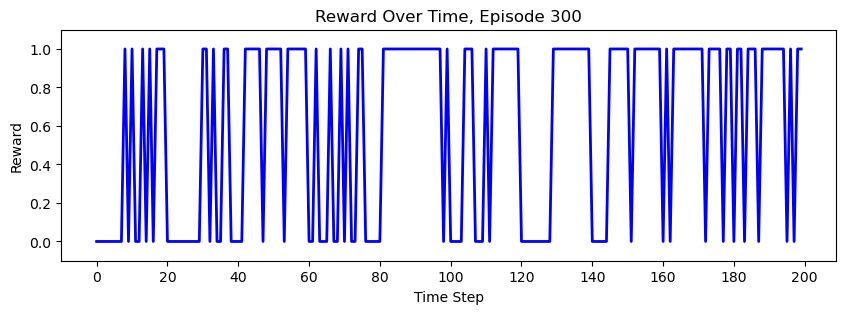

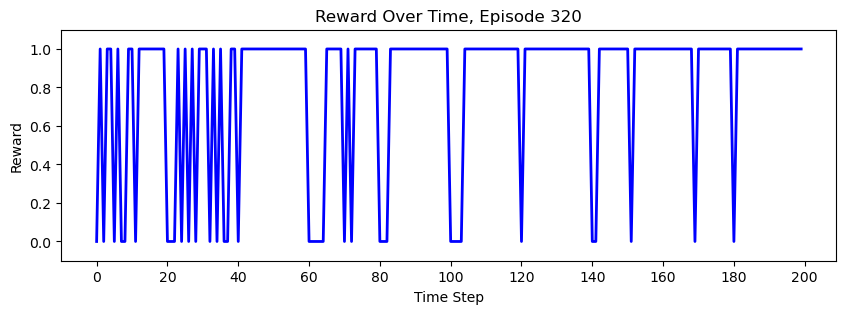

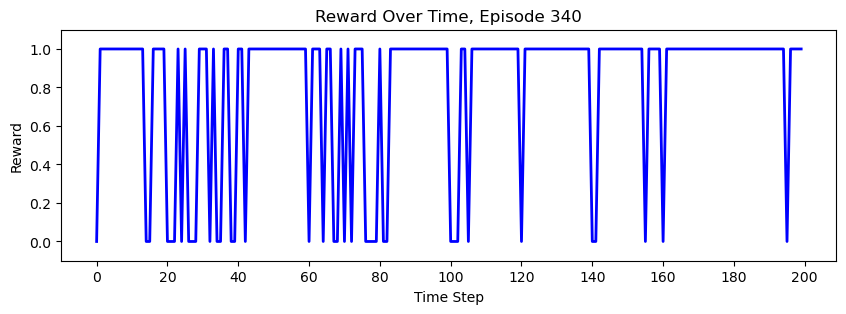

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

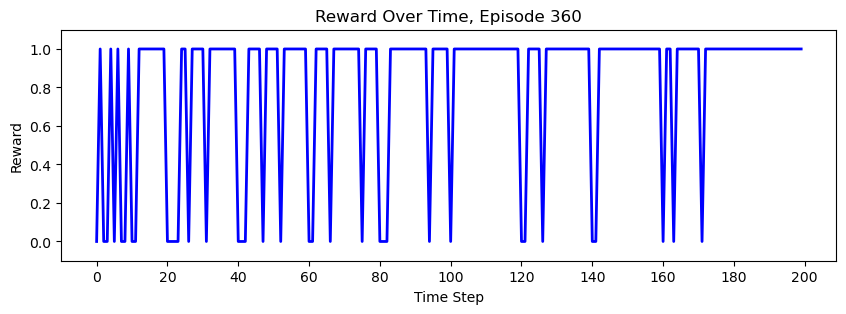

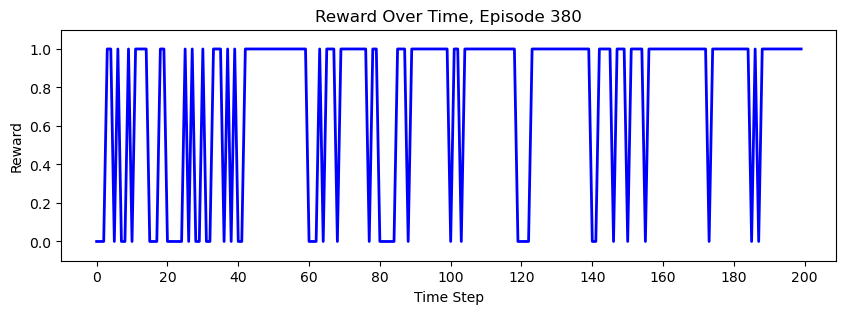

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

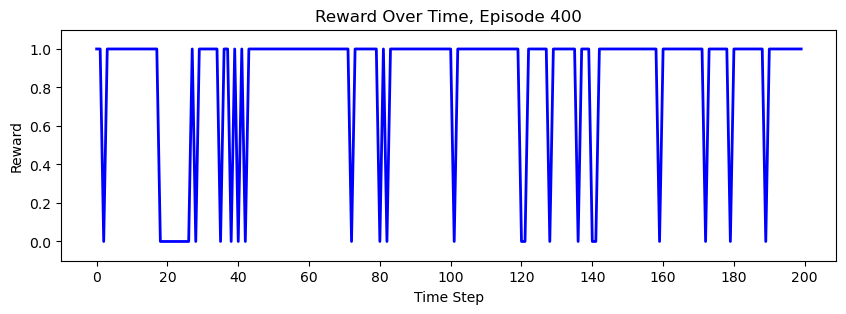

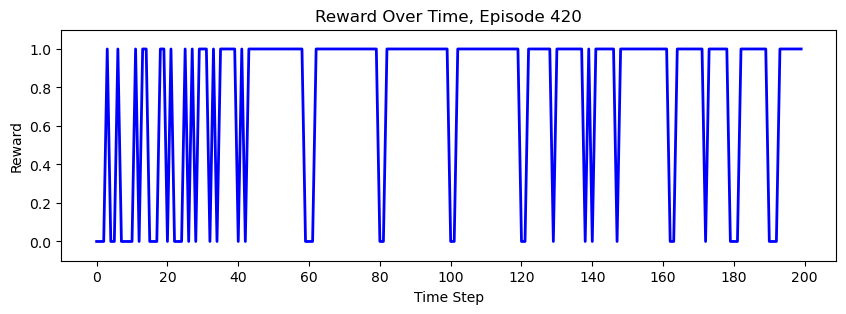

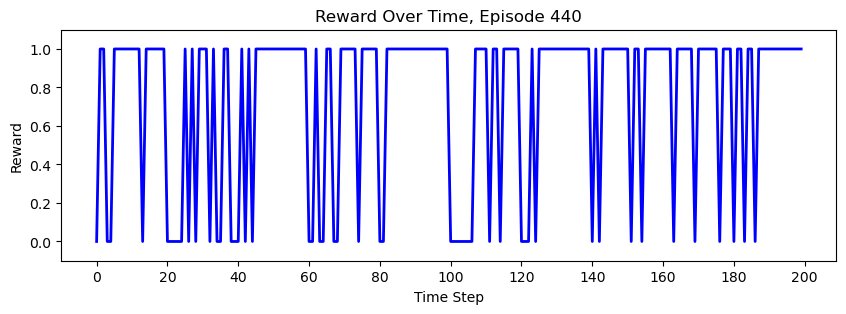

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

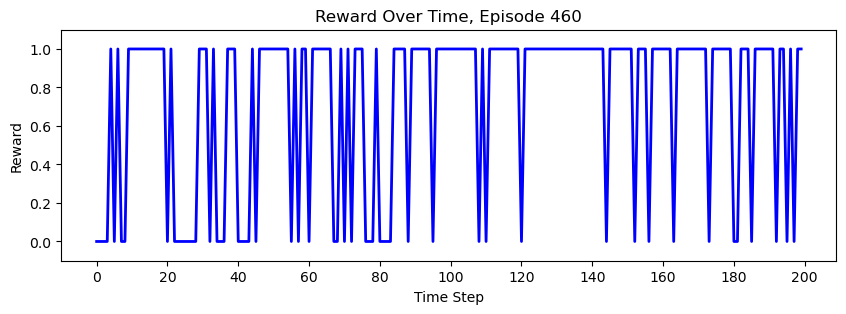

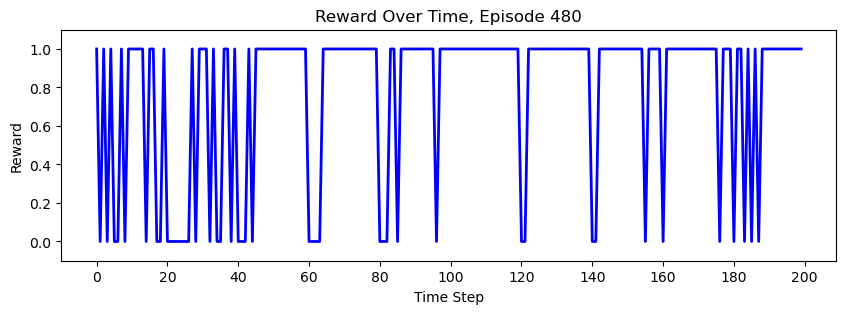

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

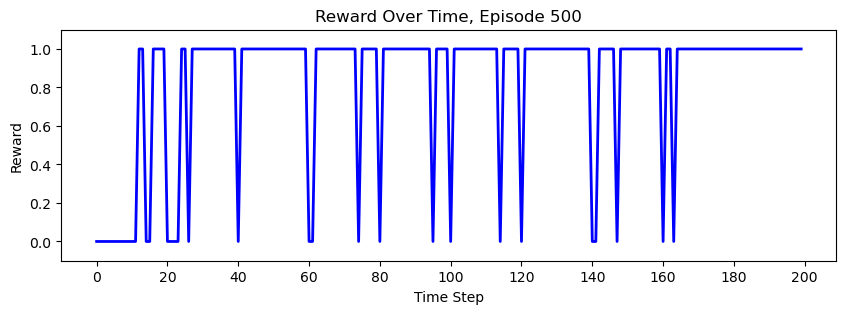

In [ ]:
# print_level = 0

# start = 0
# for j in range((B + b - 1) // b):
#     end = min(start + b, B)
#     res_name = f"results_{start}_{end}"
#     results = []
#     for i in tqdm(range(start, end), desc="Batches"):
#         # Initialize history buffers
#         exp_history = ExperimentHistory()
#         sub_history = IOPFSubjectHistory()

#         contexts, states, observations, context_r_params = extract_context_params(
#             results_folder, episode_idx=0
#         )

#         env = ExperimentalCRP(
#             context_r_params=context_r_params,
#             contexts=contexts,
#             states=states,
#             observations=observations,
#         )

#         # Initialize ensemble
#         subject = IdealObsPF(N=N_particles, hyp_params=HYP, n_workers=8)

#         env.episode(
#             subject,
#             experiment_history=exp_history,
#             subject_history=sub_history,
#             print_level=print_level,
#         )

#         subject.deallocate()

#         combined_history = CombinedHistory(
#             subject_history=sub_history, experiment_history=exp_history
#         )

#         results.append(combined_history)

#         if i % 20 == 0:
#             plt.figure(figsize=(10, 3))
#             plt.plot(
#                 combined_history.experiment_history.reward,
#                 label="Reward",
#                 color="blue",
#                 linewidth=2,
#             )
#             plt.title(f"Reward Over Time, Episode {i}")
#             plt.xlabel("Time Step")
#             plt.ylabel("Reward")
#             plt.xticks(range(0, T + 1, ctx_length))
#             plt.ylim(-0.1, 1.1)
#             plt.show()

#         # Explicitly remove per-episode objects
#         del combined_history
#         del exp_history
#         del sub_history
#         del env
#         del subject

#     # Save batch
#     with open(results_dcoin_folder / f"{res_name}.pkl", "wb") as f:
#         pickle.dump(results, f)

#     # Free the entire batch
#     del results
#     gc.collect()

#     start = end

In [6]:
proportion_optimal_mean = np.zeros(T)
n_results = 0

for start in range(0, B, b):

    end = min(start + b, B)
    filename = f"results_{start}_{end}.pkl"

    print(f"Loading {filename}")

    with open(results_dcoin_folder / filename, "rb") as f:
        batch_results = pickle.load(f)

    for result in batch_results:
        proportion_optimal_mean += np.asarray(result.experiment_history.reward)

    n_results += len(batch_results)

    del batch_results

proportion_optimal_mean /= n_results

Loading results_0_50.pkl
Loading results_50_100.pkl
Loading results_100_150.pkl
Loading results_150_200.pkl
Loading results_200_250.pkl
Loading results_250_300.pkl
Loading results_300_350.pkl
Loading results_350_400.pkl
Loading results_400_450.pkl
Loading results_450_500.pkl
Loading results_500_512.pkl


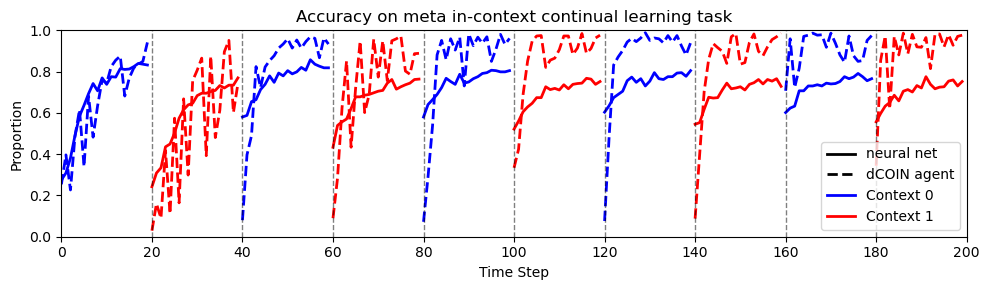

In [7]:
acc = np.loadtxt(results_folder / "acc")

from scipy.ndimage import gaussian_filter1d


def smooth(result):
    return gaussian_filter1d(result, sigma=1.5)


smooth_plot = False

plt.figure(figsize=(10, 3))

for start in range(0, T, ctx_length):
    end = min(start + ctx_length, T)
    duration = np.arange(start, end)

    # Alternate blue/red by context
    color = "blue" if (start // ctx_length) % 2 == 0 else "red"

    # Task: dashed
    if smooth_plot:
        task = smooth(proportion_optimal_mean[start:end])
        acc_tmp = smooth(acc[start:end])
    else:
        task = proportion_optimal_mean[start:end]
        acc_tmp = acc[start:end]
    plt.plot(
        duration,
        task,
        color=color,
        linestyle="--",
        linewidth=2,
    )

    # Agent accuracy: solid
    plt.plot(
        duration,
        acc_tmp,
        color=color,
        linestyle="-",
        linewidth=2,
    )

    # Task switch
    if start > 0:
        plt.axvline(
            start,
            color="black",
            linestyle="--",
            linewidth=1,
            alpha=0.5,
        )

plt.title("Accuracy on meta in-context continual learning task")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, T)
plt.xticks(range(0, T + 1, ctx_length))

# Legend: line styles
plt.plot([], [], color="black", linestyle="-", linewidth=2, label="neural net")
plt.plot([], [], color="black", linestyle="--", linewidth=2, label="dCOIN agent")


# Legend: contexts
plt.plot([], [], color="blue", linewidth=2, label="Context 0")
plt.plot([], [], color="red", linewidth=2, label="Context 1")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
proportion_optimal_mean2 = np.zeros(T)
n_results = 0

for start in range(0, B, b):

    end = min(start + b, B)
    filename = f"results_{start}_{end}.pkl"

    print(f"Loading {filename}")

    with open(results_folder / "dCOIN" / "cab" / filename, "rb") as f:
        batch_results = pickle.load(f)

    for result in batch_results:
        proportion_optimal_mean2 += np.asarray(result.experiment_history.reward)

    n_results += len(batch_results)

    del batch_results

proportion_optimal_mean2 /= n_results

Loading results_0_50.pkl
Loading results_50_100.pkl
Loading results_100_150.pkl
Loading results_150_200.pkl
Loading results_200_250.pkl
Loading results_250_300.pkl
Loading results_300_350.pkl
Loading results_350_400.pkl
Loading results_400_450.pkl
Loading results_450_500.pkl
Loading results_500_512.pkl


In [5]:
acc = np.loadtxt(results_folder / "acc")

from scipy.ndimage import gaussian_filter1d


def smooth(result):
    return gaussian_filter1d(result, sigma=1.5)


smooth_plot = False

plt.figure(figsize=(10, 3))

for start in range(0, T, ctx_length):
    end = min(start + ctx_length, T)
    duration = np.arange(start, end)

    # Alternate blue/red by context
    color = "blue" if (start // ctx_length) % 2 == 0 else "red"

    # Task: dashed
    if smooth_plot:
        task = smooth(proportion_optimal_mean[start:end])
        acc_tmp = smooth(acc[start:end])
    else:
        task = proportion_optimal_mean[start:end]
        task2 = proportion_optimal_mean2[start:end]

        acc_tmp = acc[start:end]
    plt.plot(
        duration,
        task,
        color=color,
        linestyle="--",
        linewidth=2,
    )
    plt.plot(
        duration,
        task2,
        color=color,
        linestyle=":",
        linewidth=2,
    )

    # Agent accuracy: solid
    plt.plot(
        duration,
        acc_tmp,
        color=color,
        linestyle="-",
        linewidth=2,
    )

    # Task switch
    if start > 0:
        plt.axvline(
            start,
            color="black",
            linestyle="--",
            linewidth=1,
            alpha=0.5,
        )

plt.title("Accuracy on meta in-context continual learning task")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, T)
plt.xticks(range(0, T + 1, ctx_length))

# Legend: line styles
plt.plot([], [], color="black", linestyle="-", linewidth=2, label="neural net")
plt.plot([], [], color="black", linestyle="--", linewidth=2, label="dCOIN CAB")
plt.plot([], [], color="black", linestyle=":", linewidth=2, label="dCOIN CCEB")


# Legend: contexts
plt.plot([], [], color="blue", linewidth=2, label="Context 0")
plt.plot([], [], color="red", linewidth=2, label="Context 1")

plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'proportion_optimal_mean' is not defined

<Figure size 1000x300 with 0 Axes>

## Part 3: Analysis of Results

### Visualisation of Results

In [6]:
res_name = "results_500_512"

In [7]:
with open(results_dcoin_folder / f"{res_name}.pkl", "rb") as f:
    results = pickle.load(f)

Context O History:


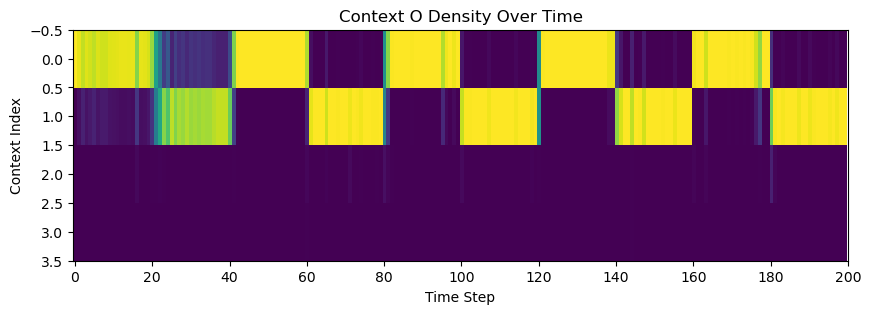

Context R History:


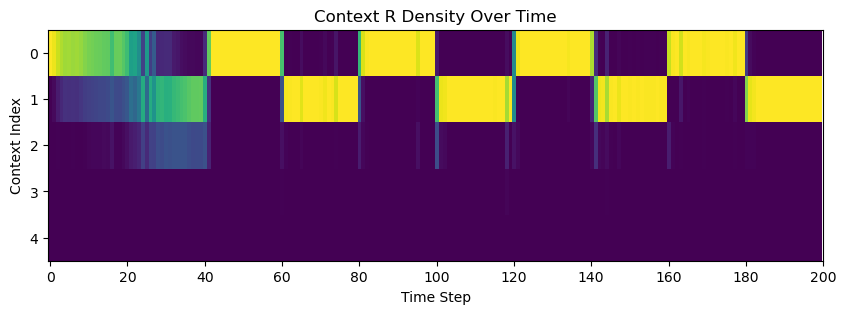

Actions History:


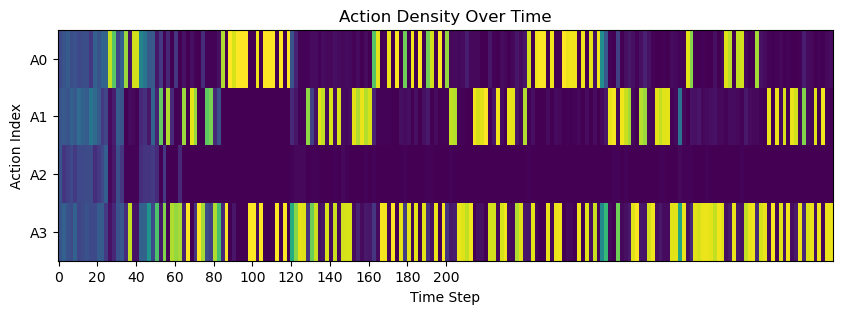

Proportion of Optimal Actions Over Time:


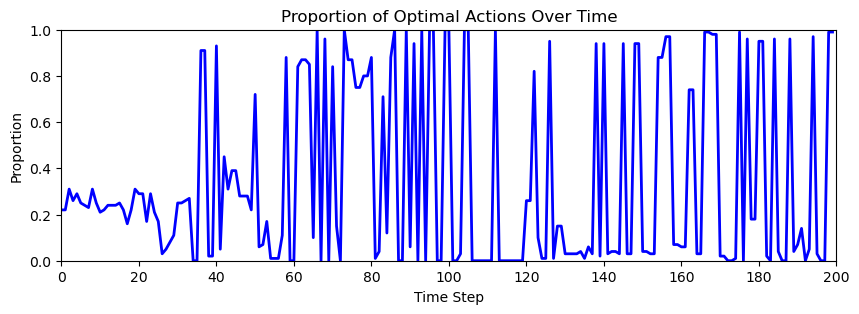

Jump History:


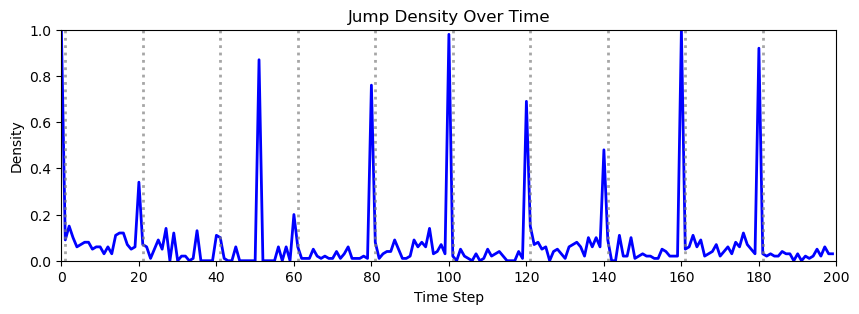

Inferred S History:


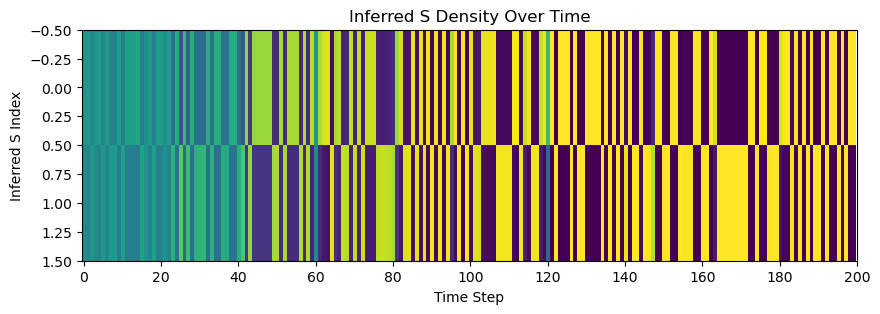

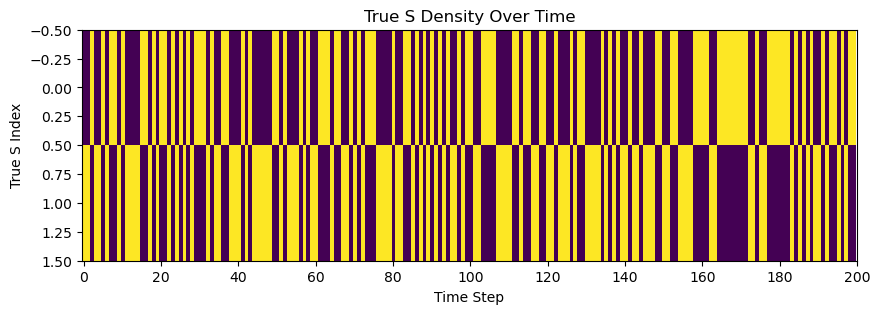

In [8]:
jump_times = []
j = 0
context_o_hist_arr = np.array(results[j].subject_history.context_o)
context_r_hist_arr = np.array(results[j].subject_history.context_r)
p_actions_arr = np.array(results[j].subject_history.p_action)
p_jump_arr = np.array(results[j].subject_history.p_jump)
p_state_arr = np.array(results[j].subject_history.p_state)
weight_arr = np.array(results[j].subject_history.weights)
p_action_optimal = results[j].p_optimal_action

print("Context O History:")
max_context_o = np.max(context_o_hist_arr) + 1
context_o_densities = np.zeros((len(context_o_hist_arr), max_context_o))
for t, element in enumerate(context_o_hist_arr):
    for particle_id, val in enumerate(element):
        context_o_densities[t, val] += weight_arr[t][particle_id]
context_o_densities = context_o_densities / context_o_densities.sum(
    axis=1, keepdims=True
)

# set size of plot
plt.figure(figsize=(10, 3))
plt.imshow(
    context_o_densities.T, aspect="auto", cmap="viridis", interpolation="nearest"
)
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)


plt.xlabel("Time Step")
plt.ylabel("Context Index")
plt.title("Context O Density Over Time")
plt.xticks(range(0, T + 1, ctx_length))
# plt.savefig("g_context_o_density.pdf")
plt.show()

print("Context R History:")
max_context_r = np.max(context_r_hist_arr) + 1
context_r_densities = np.zeros((len(context_r_hist_arr), max_context_r))
for t, element in enumerate(context_r_hist_arr):
    for particle_id, val in enumerate(element):
        context_r_densities[t, val] += weight_arr[t][particle_id]
context_r_densities = context_r_densities / context_r_densities.sum(
    axis=1, keepdims=True
)

plt.figure(figsize=(10, 3))
plt.imshow(
    context_r_densities.T, aspect="auto", cmap="viridis", interpolation="nearest"
)
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Context Index")
plt.title("Context R Density Over Time")
plt.xticks(range(0, T + 1, ctx_length))
# plt.savefig("g_context_r_density.pdf")
plt.show()


print("Actions History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_actions_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
plt.yticks(ticks=[0, 1, 2, 3], labels=["A0", "A1", "A2", "A3"])
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Action Index")
plt.title("Action Density Over Time")
# plt.savefig("g_action_density.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()

print("Proportion of Optimal Actions Over Time:")

plt.figure(figsize=(10, 3))
plt.plot(p_action_optimal, label="Proportion Optimal Action", color="blue", linewidth=2)
plt.title("Proportion of Optimal Actions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, len(p_action_optimal))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
# plt.savefig("g_proportion_optimal.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()

print("Jump History:")

plt.figure(figsize=(10, 3))
plt.plot(p_jump_arr, label="Jump", color="blue", linewidth=2)
plt.title("Jump Density Over Time")
plt.xlabel("Time Step")
plt.ylabel("Density")
plt.ylim(0, 1)
plt.xlim(0, len(p_jump_arr))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
for i in range(1, 201, 20):
    plt.axvline(i, color="grey", linestyle=":", linewidth=2, alpha=0.7)
# plt.savefig("g_jump_density.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()

print("Inferred S History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_state_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Inferred S Index")
plt.title("Inferred S Density Over Time")
plt.xticks(range(0, T + 1, ctx_length))
# plt.savefig("g_inferred_s_density.pdf")
plt.show()


true_s_hist_arr = np.asarray(results[j].experiment_history.state)

plt.figure(figsize=(10, 3))
true_s_densities = np.zeros((len(true_s_hist_arr), 2))
for idx, val in enumerate(true_s_hist_arr):
    true_s_densities[idx, int(val)] += 1
true_s_densities = true_s_densities / true_s_densities.sum(axis=1, keepdims=True)
plt.imshow(true_s_densities.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("True S Index")
plt.title("True S Density Over Time")
plt.xticks(range(0, T + 1, ctx_length))
# plt.savefig("g_true_s_density.pdf")
plt.show()